Loading CIFAR-10 data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting Training (this may take a few minutes)...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 42ms/step - accuracy: 0.4410 - loss: 1.5350 - val_accuracy: 0.5170 - val_loss: 1.3633
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.5819 - loss: 1.1787 - val_accuracy: 0.5961 - val_loss: 1.1284
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 39ms/step - accuracy: 0.6383 - loss: 1.0280 - val_accuracy: 0.6184 - val_loss: 1.0534
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - accuracy: 0.6715 - loss: 0.9328 - val_accuracy: 0.6607 - val_loss: 0.9527
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6971 - loss: 0.8640 - val_accuracy: 0.6713 - val_loss: 0.9448
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.7188 - loss: 0.8012 - val_accuracy: 0.6753 - val_loss: 0.9453
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.7335 - loss: 0.7574 - val_accuracy: 0.6968 - val_loss: 0.8823
Epoch 8/10
1563/1563 ━━━

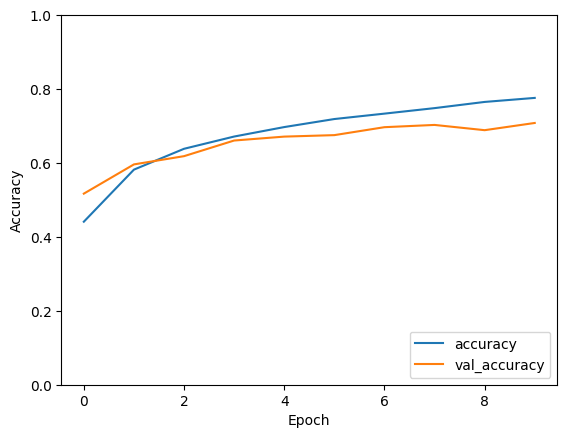

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load the CIFAR-10 dataset
print("Loading CIFAR-10 data...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# 2. Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Define class names for visualization
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 3. Build the CNN Model
# We use a slightly deeper architecture for these color images
model = models.Sequential([
    # First block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third block
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Classification Head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 output neurons for 10 classes
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the Model
print("\nStarting Training (this may take a few minutes)...")
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# 6. Evaluate the Model
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nFinal Test Accuracy: {test_acc*100:.2f}%')

# 7. (Optional) Visualize training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()